<a href="https://colab.research.google.com/github/MehediHasanUthan/ml-journey/blob/main/projects/day02_visualize_and_augment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Block 2**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


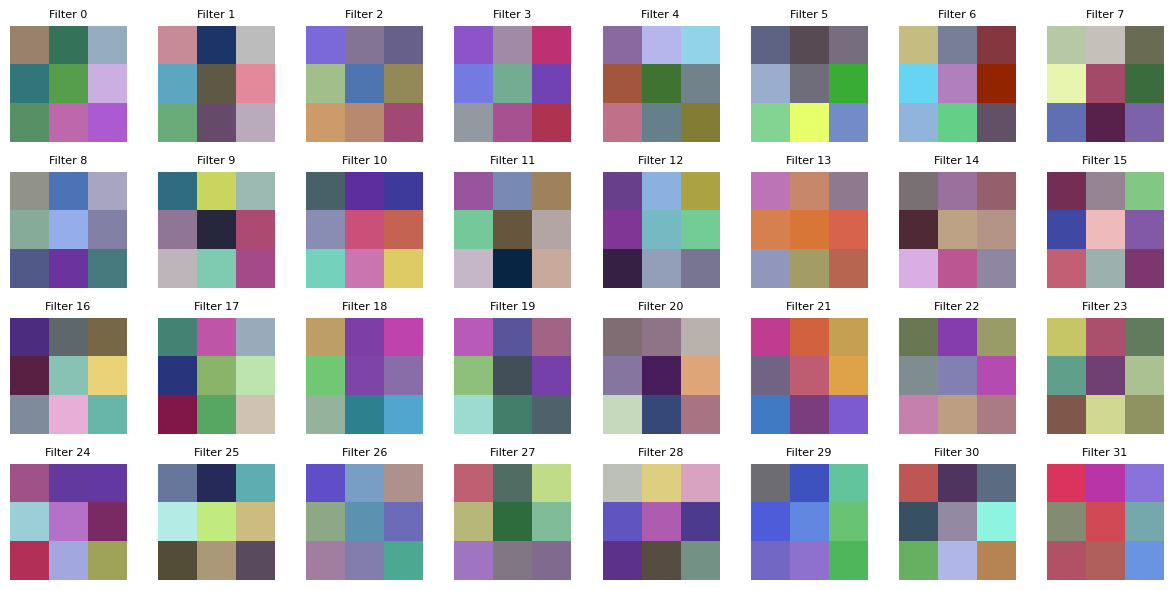

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/Colab Notebooks'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32 → 16
        x = self.pool(F.relu(self.conv2(x)))   # 16 → 8
        x = self.pool(F.relu(self.conv3(x)))   # 8  → 4
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CIFAR10_CNN(num_classes=10).to(device)
model.load_state_dict(torch.load(f'{PROJECT}/day01_model.pth'))
model.eval()

filters = model.conv1.weight.data.cpu().clone()    # shape: [32, 3, 3, 3]

# Normalizing each filter to [0, 1] so it's viewable as an image
# filter weights can be negative
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    filt=filters[i]
    filt = filt.permute(1, 2, 0)
    ax.imshow(filt)
    ax.axis('off')
    ax.set_title(f'Filter {i}', fontsize=8)
plt.tight_layout()
plt.show()

# **Block3**

100%|██████████| 170M/170M [00:05<00:00, 29.1MB/s]


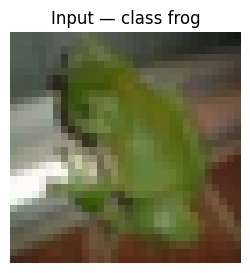

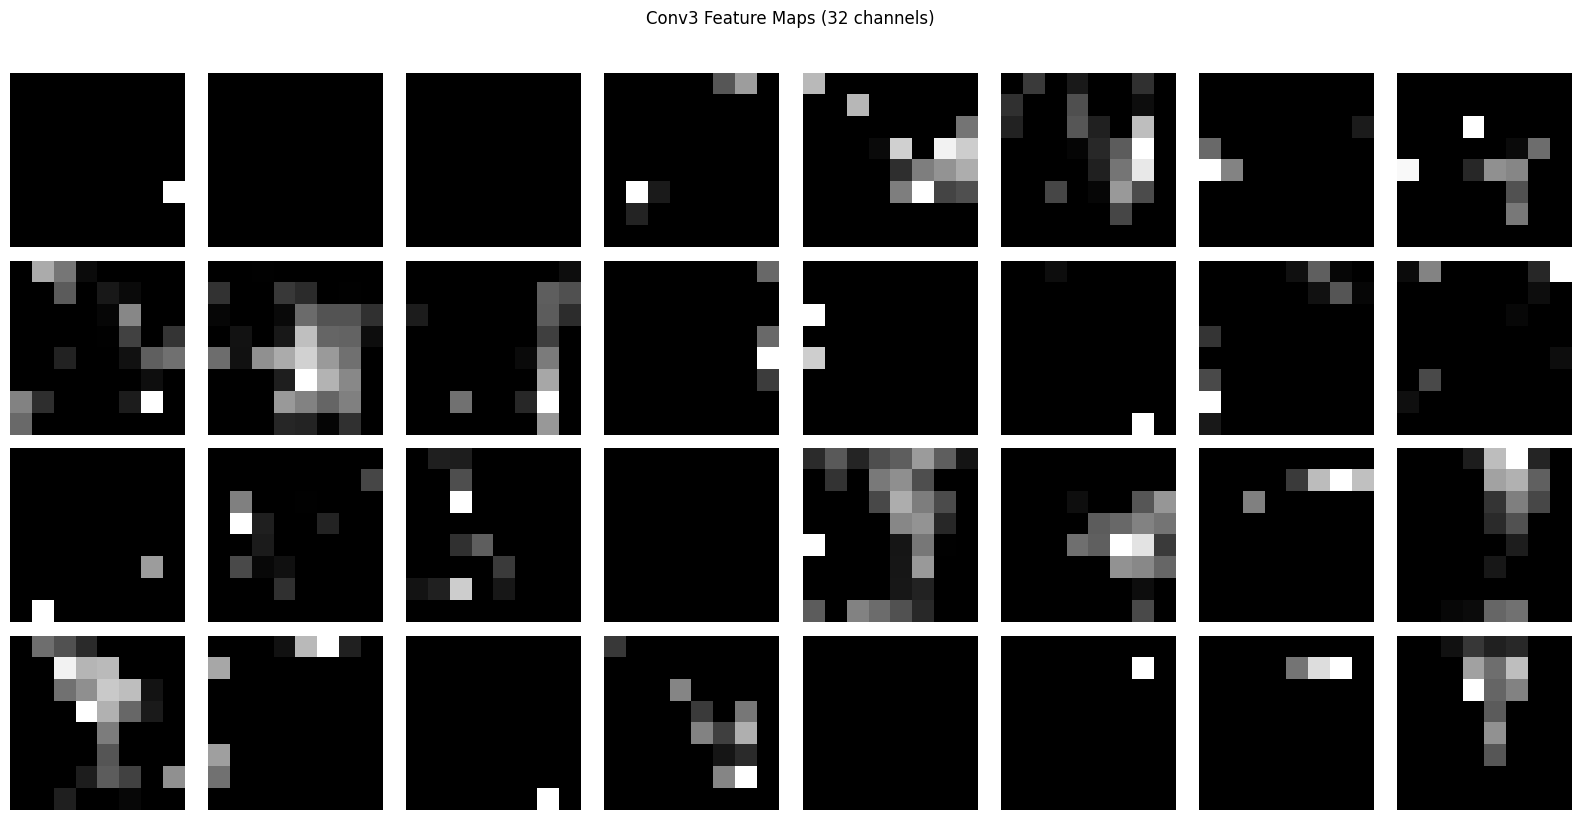

In [ ]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
# Picking one test image
img, label = test_dataset[7]
img_batched = img.unsqueeze(0).to(device)   # shape [1, 3, 32, 32]

# Forward pass manually, layer by layer, keeping intermediate outputs
with torch.no_grad():
    a1 = F.relu(model.conv1(img_batched))   # shape [1, 32, 32, 32]
    p1 = model.pool(a1)                     # shape [1, 32, 16, 16]
    a2 = F.relu(model.conv2(p1))            # shape [1, 64, 16, 16]
    p2 = model.pool(a2)                     # shape [1, 64, 8, 8]
    a3 = F.relu(model.conv3(p2))            # shape [1, 128, 8, 8]

# Display the original image first
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0) * 0.5 + 0.5)  # un-normalize for display
plt.title(f'Input — class {classes[label]}')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(a3[0, i].cpu(), cmap='gray')
    ax.axis('off')
plt.suptitle('Conv3 Feature Maps (32 channels)', y=1.02)
plt.tight_layout()
plt.show()

# **Block 4**

In [ ]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Augmented training transform
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Test transform — NEVER augment test data
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Fresh datasets and loaders
train_dataset_aug = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset_clean = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True, num_workers=2)
test_loader_clean = DataLoader(test_dataset_clean, batch_size=64, shuffle=False, num_workers=2)

# Fresh model — important: start from scratch, not the trained Day 1 weights
model_aug = CIFAR10_CNN(num_classes=10).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    model.train()
    return 100. * correct / total

def train(model, optimizer, train_loader, test_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        train_acc = 100. * correct / total
        test_acc  = evaluate(model, test_loader)
        avg_loss  = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}]  Loss: {avg_loss:.3f}  Train Acc: {train_acc:.2f}%  Test Acc: {test_acc:.2f}%")

train(model_aug, optimizer_aug, train_loader_aug, test_loader_clean, epochs=10)



Epoch [1/10]  Loss: 1.570  Train Acc: 42.38%  Test Acc: 55.82%
Epoch [2/10]  Loss: 1.185  Train Acc: 57.44%  Test Acc: 65.68%
Epoch [3/10]  Loss: 0.988  Train Acc: 64.94%  Test Acc: 69.35%
Epoch [4/10]  Loss: 0.880  Train Acc: 69.09%  Test Acc: 71.77%
Epoch [5/10]  Loss: 0.805  Train Acc: 71.71%  Test Acc: 73.97%
Epoch [6/10]  Loss: 0.754  Train Acc: 73.39%  Test Acc: 75.23%
Epoch [7/10]  Loss: 0.708  Train Acc: 75.19%  Test Acc: 76.68%
Epoch [8/10]  Loss: 0.678  Train Acc: 76.12%  Test Acc: 76.95%
Epoch [9/10]  Loss: 0.647  Train Acc: 77.42%  Test Acc: 78.36%
Epoch [10/10]  Loss: 0.627  Train Acc: 77.93%  Test Acc: 78.50%


In [ ]:
torch.save(model_aug.state_dict(), f'{PROJECT}/day02_model_aug.pth')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


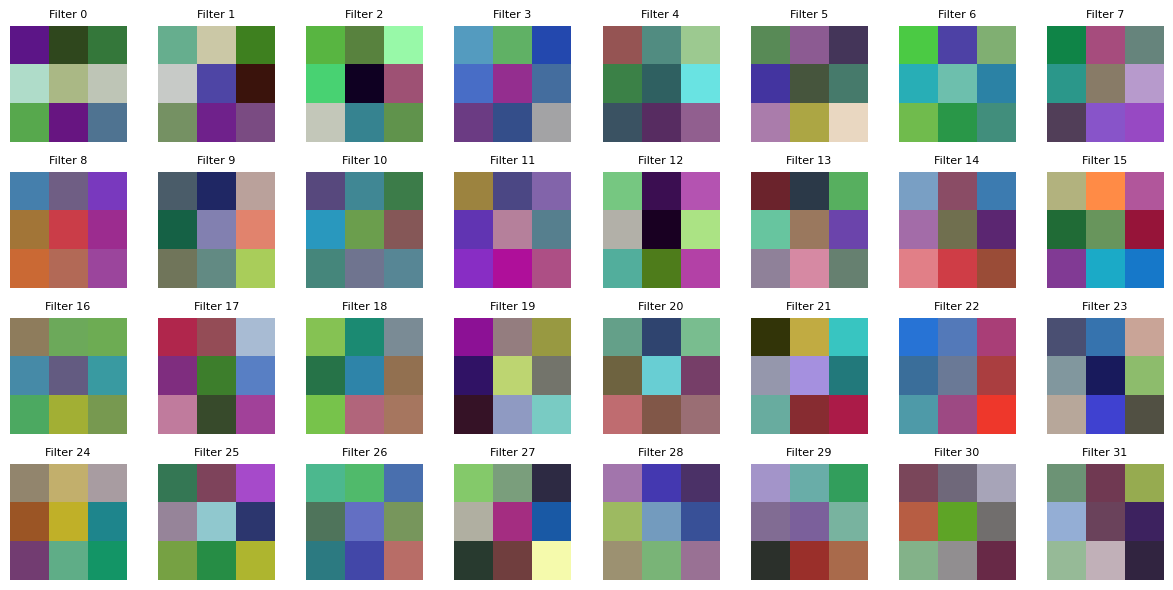

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/Colab Notebooks'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(128 * 4 * 4, 256)
        self.fc2   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32 → 16
        x = self.pool(F.relu(self.conv2(x)))   # 16 → 8
        x = self.pool(F.relu(self.conv3(x)))   # 8  → 4
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CIFAR10_CNN(num_classes=10).to(device)
model.load_state_dict(torch.load(f'{PROJECT}/day02_model_aug.pth'))
model.eval()

filters = model.conv1.weight.data.cpu().clone()    # shape: [32, 3, 3, 3]

# Normalizing each filter to [0, 1] so it's viewable as an image
# filter weights can be negative
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    filt=filters[i]
    filt = filt.permute(1, 2, 0)
    ax.imshow(filt)
    ax.axis('off')
    ax.set_title(f'Filter {i}', fontsize=8)
plt.tight_layout()
plt.show()